# 02_conditional_edges

对应 `index.md` 第 2 阶段：条件边、`END`、手写 ReAct 图（agent ↔ tools 循环）。

笔记本在 `codes/langgraph/02_conditional_edges/qa.ipynb`。需要读写文件时，工作空间就是这个目录。

先运行下一格，得到 `ROOT` 并加载 `codes/langgraph/local.env`。每题只改 `# 作答` 下面的代码。前置代码不用改。做完自己跑通即可，先不要对答案。

第 1 阶段只连静态边，图是直的一条线。本阶段加**条件边**：下一步走哪，由 router 函数根据当前 state 现场决定。这才让图能分支、能循环——把 `codes/langchain/08_agents` 里手写的那个 `while` 循环，画成 `agent ↔ tools` 的显式图。第 4 题真的要调 API，会慢。

In [1]:
import os
from pathlib import Path

def lab_root() -> Path:
    """qa.ipynb 所在目录。"""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if folder.name == "02_conditional_edges" and (folder / "qa.ipynb").is_file():
            return folder
        candidate = folder / "codes" / "langgraph" / "02_conditional_edges"
        if (candidate / "qa.ipynb").is_file():
            return candidate
    return here

def load_local_env(env_path: Path) -> None:
    """把 local.env 写入 os.environ（已有键不覆盖）。"""
    if not env_path.is_file():
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        value = value.strip().strip("\"'")
        if key and key not in os.environ:
            os.environ[key] = value

ROOT = lab_root()
load_local_env(ROOT.parent / "local.env")
ROOT, bool(os.environ.get("DEEPSEEK_API_KEY"))

(PosixPath('/Users/keyficller/Documents/AEFS-Notes/codes/langgraph/02_conditional_edges'),
 True)

## 1. 第一条条件边

静态边 `add_edge(a, b)` 写死去 `b`。条件边 `add_conditional_edges(起点, router, path_map)` 把「去哪」交给一个**路由函数**：它读 state，返回下一步的**节点名**（或 `END`）。

已有 State `Route`（`value: int`、`label: str`）和两个终点节点 `big` / `small`（各写自己的 `label`）。

1. 写 `router(state)`：`value >= 10` 返回 `"big"`，否则返回 `"small"`
2. 建图：注册 `big`、`small`
3. 从 `START` 挂条件边 `add_conditional_edges(START, router, {"big": "big", "small": "small"})`
4. 两个终点各接静态边到 `END`
5. `compile` 后分别 `invoke({"value": 42})` 和 `invoke({"value": 3})`，打印 `label`

`path_map` 是「router 的返回值 → 真实节点名」的映射表，避免 router 直接依赖节点名。

big
small


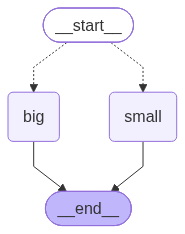

In [2]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

class Route(TypedDict):
    value: int
    label: str

def big(state: Route) -> dict:
    return {"label": "big"}

def small(state: Route) -> dict:
    return {"label": "small"}

# 作答

def router(state: Route) -> str:
    return "big" if state["value"] >= 10 else "small"

graph = StateGraph(Route)

graph.add_node("big", big)
graph.add_node("small", small)

graph.add_conditional_edges(
    START,
    router,
    {
        "big": "big",
        "small": "small"
    }
)

graph.add_edge("big", END)
graph.add_edge("small", END)

app = graph.compile()

print(app.invoke({"value": 42})["label"])
print(app.invoke({"value": 3})["label"])

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
#评阅
# 对。router 分段正确，path_map 对，START 挂条件边、两个终点各接 END，输出 big / small。
# 之前那版多挂的 add_node("router", router) 已删掉——对，router 是路由函数不是节点。
# 小点：draw_mermaid_png() 要联网下载图片，离线会失败；只想看结构用 draw_mermaid() 出文本更稳。

#参考答案
# def router(state: Route) -> str:
#     return "big" if state["value"] >= 10 else "small"
#
# graph = StateGraph(Route)
# graph.add_node("big", big)
# graph.add_node("small", small)
# graph.add_conditional_edges(START, router, {"big": "big", "small": "small"})
# graph.add_edge("big", END)
# graph.add_edge("small", END)
# app = graph.compile()
# print(app.invoke({"value": 42})["label"])
# print(app.invoke({"value": 3})["label"])

## 2. 用 `END` 让自环停下来

条件边指回自己，就是一个循环。**必须留一个出口**，否则图永远转下去。路由函数返回 `END`（就是第 1 阶段那两个哨兵之一）表示「到此结束」。

已有 State `Count`（`count: int`）和节点 `tick`（`count` 加一）。

1. 写 `router(state)`：`count < 3` 就返回 `"tick"`（再转一圈），否则返回 `END`
2. 建图：注册 `tick`，静态边 `START → tick`
3. 条件边从 `tick` 出发，`path_map` 要**同时**给出两个去向：`{"tick": "tick", END: END}`
4. `compile` 后 `invoke({"count": 0})`，打印最终的 `count`（应该是 3）

注意 `END` 可以直接当 `path_map` 的键，不用改写成字符串。

3


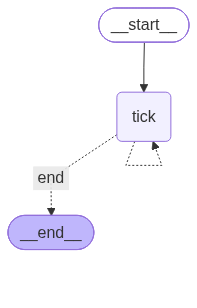

In [3]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

class Count(TypedDict):
    count: int

def tick(state: Count) -> dict:
    return {"count": state["count"] + 1}

# 作答


def router(state: Count) -> str:
    return "tick" if state["count"] < 3 else "end"

graph = StateGraph(Count)

graph.add_node("tick", tick)
graph.add_edge(START, "tick")
graph.add_conditional_edges(
    "tick",
    router,
    {
        "tick": "tick",
        "end": END
    }
)

app = graph.compile()

print(app.invoke({"count": 0})["count"])

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
#评阅
# 对，count 停在 3。你把出口写成字符串 "end"、再在 path_map 里映射 "end": END——可行，
# 和题面写的「直接返回 END」等价；两种都行。
# 小点：同上，draw_mermaid_png 需联网。

#参考答案
# def router(state: Count) -> str:
#     return "tick" if state["count"] < 3 else END
#
# graph = StateGraph(Count)
# graph.add_node("tick", tick)
# graph.add_edge(START, "tick")
# graph.add_conditional_edges("tick", router, {"tick": "tick", END: END})
# print(graph.compile().invoke({"count": 0})["count"])

## 3. 一个 router 分三路

路由函数可以有很多分支，`path_map` 就是那张对照表。分支一多，它的价值更明显：router 只负责「判断」，节点名映射留在 `path_map`。

已有 State `Mood`（`text: str`、`mood: str`）和三个节点 `happy` / `sad` / `neutral`（各写自己的 `mood`）。

1. 写 `router(state)`：`text` 含 `"好棒"` → `"happy"`；含 `"太差"` → `"sad"`；否则 `"neutral"`
2. 建图：三个节点都注册，各接静态边到 `END`
3. 从 `START` 挂条件边，`path_map` 写全三路
4. `compile` 后对 `["今天好棒", "太差了", "就这样吧"]` 各 `invoke` 一次，逐条打印 `mood`

happy
sad
neutral


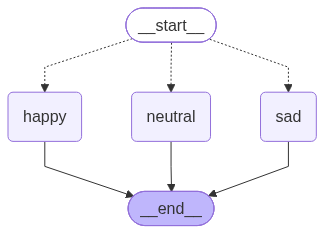

In [4]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

class Mood(TypedDict):
    text: str
    mood: str

def happy(state: Mood) -> dict:
    return {"mood": "happy"}

def sad(state: Mood) -> dict:
    return {"mood": "sad"}

def neutral(state: Mood) -> dict:
    return {"mood": "neutral"}

# 作答

def router(state: Mood) -> str:
    return "happy" if "好棒" in state["text"]\
        else "sad" if "太差" in state["text"]\
        else "neutral"

graph = StateGraph(Mood)

graph.add_node("happy", happy)
graph.add_node("sad", sad)
graph.add_node("neutral", neutral)

graph.add_conditional_edges(
    START,
    router,
    {
        "happy": "happy",
        "sad": "sad",
        "neutral": "neutral"
    }
)

app = graph.compile()

print(app.invoke({"text": "今天好棒"})["mood"])
print(app.invoke({"text": "太差了"})["mood"])
print(app.invoke({"text": "就这样吧"})["mood"])

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
#评阅
# 对，三路都命中：happy / sad / neutral。
# 三元链配行尾反斜杠能跑，但偏挤；同一条判断写成 if/elif 更好读（参考答案）。
# 小点：draw_mermaid_png 需联网。

#参考答案
# def router(state: Mood) -> str:
#     if "好棒" in state["text"]:
#         return "happy"
#     if "太差" in state["text"]:
#         return "sad"
#     return "neutral"
#
# graph = StateGraph(Mood)
# for name, fn in [("happy", happy), ("sad", sad), ("neutral", neutral)]:
#     graph.add_node(name, fn)
#     graph.add_edge(name, END)
# graph.add_conditional_edges(START, router, {"happy": "happy", "sad": "sad", "neutral": "neutral"})
# app = graph.compile()
# for text in ["今天好棒", "太差了", "就这样吧"]:
#     print(app.invoke({"text": text})["mood"])

## 4. 手写 ReAct 图（本阶段主菜）

把 `codes/langchain/08_agents` 里手写的 `while` 循环，改画成 `agent ↔ tools` 的图。四样东西：

- **节点 `agent`**：调模型，把回复（可能带 `tool_calls`）追加进 `messages`
- **路由 `should_continue`**：最后一条消息有 `tool_calls` → `"tools"`，否则 `END`
- **节点 `run_tools`**：遍历最后一条消息的 `tool_calls`，逐个执行，每个结果包成 `ToolMessage`（`tool_call_id` 要对齐）返回
- **边**：`START → agent`；`agent` 条件边 → `tools` / `END`；`tools` 静态边 → `agent`

已有绑定好工具的 `bound`、`tools_by_name`、`MessagesState`。

接好后 `invoke({"messages": [HumanMessage("先算 2+3，再把结果乘以 4。必须用工具。")]})`，打印**消息总条数**和**最后一条的 `content`**。

跑通后回看：消息序列应该长成「人类 → AI(要工具) → 工具结果 → AI(再要工具) → 工具结果 → AI(答案)」——这正是第 1 题到第 3 题那些边拼出来的循环。

In [ ]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph

@tool
def add(a: int, b: int) -> int:
    """两数相加。"""
    return a + b

@tool
def mul(a: int, b: int) -> int:
    """两数相乘。"""
    return a * b

tools_by_name = {"add": add, "mul": mul}

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)
bound = model.bind_tools([add, mul])

# 作答

def agent(state: MessagesState) -> dict:
    return {"messages": [bound.invoke(state["messages"])]}

def should_continue(state: MessagesState) -> str:
    return "tools" if state["messages"][-1].tool_calls else "end"

def run_tools(state: MessagesState) -> dict:
    tool_calls = state["messages"][-1].tool_calls
    tool_observes = [
        ToolMessage(
        content=str(tools_by_name[call["name"]].invoke(call["args"])),
        tool_call_id=call["id"]
        )
        for call in tool_calls
    ]
    return {"messages": tool_observes}

graph = StateGraph(MessagesState)

graph.add_node("agent", agent)
graph.add_node("tools", run_tools)

graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)
graph.add_edge("tools", "agent")

app = graph.compile()

response = app.invoke({"messages": [HumanMessage("先算 2+3，再把结果乘以 4。必须用工具。")]})

print(len(response["messages"]))

for m in response["messages"]:
    print(type(m).__name__, m.content)

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
#评阅
# 这题没跑对，需要重做。输出只有 2 条消息（预期 6 条），根因是节点里用了 model，不是 bound。
#
# 1) 最关键：agent 节点写的是 model.invoke(...)。model 没绑工具，模型永远不会返回 tool_calls，
#    于是 should_continue 第一次就返回 "end"，图只跑一步就结束，run_tools 一次都没进。
#    应改成 bound.invoke(...)。
# 2) run_tools 里用 call.id / call.name / call.args：tool_calls 每项是 dict 不是对象
#    （08_agents 里你就是用 call["name"] 取的），要写 call["id"] / call["name"] / call["args"]。
#    换成 bound 后，这里第一处就 AttributeError: 'dict' object has no attribute 'id'。
# 3) 执行工具写成 tools_by_name[call.name](*call.args)：StructuredTool 不能直接调用，
#    要 .invoke(call["args"])；*call.args 还会把字典的键当位置参数展开，同样不对。
# 4) ToolMessage(content=..., tool_call_id=...) 才是正解：args / observation 不是 ToolMessage 的字段，
#    而且 content 是必填，工具结果要放进 content。
# 5) 返回写成 {"messages": [tool_observes]}，外面多套了一层列表；应为 {"messages": tool_observes}。
#
# 记住：tool_calls 每项是 {"name","args","id","type"} 的 dict，取值用中括号，执行工具用 .invoke(args)。

#参考答案
# def agent(state: MessagesState) -> dict:
#     return {"messages": [bound.invoke(state["messages"])]}
#
# def should_continue(state: MessagesState) -> str:
#     return "tools" if state["messages"][-1].tool_calls else END
#
# def run_tools(state: MessagesState) -> dict:
#     msgs = []
#     for call in state["messages"][-1].tool_calls:
#         result = tools_by_name[call["name"]].invoke(call["args"])
#         msgs.append(ToolMessage(content=str(result), tool_call_id=call["id"]))
#     return {"messages": msgs}
#
# graph = StateGraph(MessagesState)
# graph.add_node("agent", agent)
# graph.add_node("tools", run_tools)
# graph.add_edge(START, "agent")
# graph.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
# graph.add_edge("tools", "agent")
# out = graph.compile().invoke({"messages": [HumanMessage("先算 2+3，再把结果乘以 4。必须用工具。")]})
# print(len(out["messages"]))
# for m in out["messages"]:
#     print(type(m).__name__, m.content)

NotImplementedError: Message as a sequence must be (role string, template)

## 5. 给循环装两道保险

循环最大的风险是「停不下来」。分两部分做。

**第一部分：看它怎么炸。** 已有 State `Loopy`（`count: int`）和节点 `tick`。写一个**永远返回 `"tick"`** 的 router，让图无限自环。用 `invoke({"count": 0}, {"recursion_limit": 5})` 跑它，**包在 `try/except` 里**，打印异常类型与消息。

**第二部分：看保险不能设太紧。** 再写一张**会正常结束**的图（和上一题同款：`count` 到 3 就返回 `END`）。先不设限制跑通；再把 `recursion_limit` 设成 **2** 跑一次——它会报同一个错。这说明 `recursion_limit` 是**执行步数的硬上限**，不是「最多几轮对话」，正常图也要留足余量。

题面只要第一部分那处 `try/except`；第二部分打印两次结果（成功 / 失败）即可。

GraphRecursionError Recursion limit of 5 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


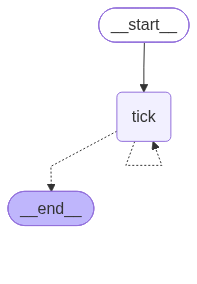

In [8]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph

class Loopy(TypedDict):
    count: int

def tick(state: Loopy) -> dict:
    return {"count": state["count"] + 1}

# 作答

def router(state: Loopy) -> str:
    return "tick"

graph = StateGraph(Loopy)

graph.add_node("tick", tick)

graph.add_edge(START, "tick")
graph.add_conditional_edges(
    "tick",
    router,
    {
        "tick": "tick"
    }
)

app = graph.compile()

try:
    print(app.invoke({"count": 0}, {"recursion_limit": 5}))
except Exception as e:
    print(type(e).__name__, str(e))

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
#评阅
# 只做了第一部分。无限自环 + recursion_limit=5 → GraphRecursionError，
# try/except 打印类型和消息，这部分对。
# 第二部分没做：再写一张「count 到 3 就 END」的正常图，先不设限制跑通，
# 再把 recursion_limit 设成 2 跑一次——它会报同一个错。那部分正是要说明：
# recursion_limit 是执行步数的硬上限，正常图也要留余量（那张图实测要 >= 4 才够）。
# 小点：draw_mermaid_png 需联网。

#参考答案
# def router_ok(state: Loopy) -> str:
#     return "tick" if state["count"] < 3 else END
#
# g = StateGraph(Loopy)
# g.add_node("tick", tick)
# g.add_edge(START, "tick")
# g.add_conditional_edges("tick", router_ok, {"tick": "tick", END: END})
# ok = g.compile()
# print(ok.invoke({"count": 0}))                    # 正常跑通 -> {'count': 3}
# try:
#     ok.invoke({"count": 0}, {"recursion_limit": 2})
# except Exception as e:
#     print(type(e).__name__, str(e))               # 同一个 GraphRecursionError